In [10]:
import cv2
from os import listdir
from os.path import isfile, join
from keras import backend as K
from keras.applications import ResNet50
from keras.models import Model
import numpy as np

from keras.preprocessing import image 


#from pretrained model: user anshu1106 on github

In [11]:
# Build model and load pretrained weights
model = ResNet50()

model.summary() # prints the summary of model with layer names and sizes

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [12]:
from keras.applications.resnet50 import preprocess_input, decode_predictions

# choose from one of the layer names 
layer_name = 'avg_pool'
emb_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)

# Create a model which returns embedding at a particular layer 

In [13]:
from keras.preprocessing import image
def display_image(img_path):
    img = cv2.imread(img_path)
    cv_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(cv_rgb)
    plt.show()
    
def preprocess_input_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x

def predict_label(img_path):
    x = preprocess_input_image(img_path)
    prediction = model.predict(x)
    print(np.argmax(prediction))
    print('Predicted:', decode_predictions(prediction, top=3)[0])
    


In [14]:
img_path= '/Users/aditibelle/Desktop/pubmed_set/images/0a6fc26c-9cd9-4f95-8273-0a416457c92e.jpg'
test_image = preprocess_input_image(img_path)
# extract embedding
# embeddings=[]
embedding = emb_model.predict(test_image)
print(embedding)
# embeddings.append(embedding)
feature_embeddings = []
feature_embeddings.append(embedding) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
[[0.07828413 0.06765559 0.         ... 0.13479476 0.06840472 0.06524852]]


In [15]:
embeddingsfile = 'embeddings.npy'
def save_embeddings(embeddings_list, embeddingsfile):
    """
    Saves embeddings as .npy file

    input: 
        embeddings_list: list of embeddings generated from model

    output:
        None

    """
    np.save(embeddingsfile, embeddings_list)

save_embeddings(feature_embeddings, embeddingsfile)

print("Saved embedding.npy")

Saved embedding.npy


In [16]:
data = np.load('embeddings.npy')

In [17]:
img_path= '/Users/aditibelle/Desktop/pubmed_set/images/0a6fc26c-9cd9-4f95-8273-0a416457c92e.jpg'
from pathlib import Path
test = Path(img_path)
test.is_file()

True

In [18]:
import matplotlib.pyplot as plt                        
%matplotlib inline 
print(embedding.shape)

(1, 2048)


In [32]:
#%%timeit
img_width = 224
img_height = 224
#vgg_path = '/Users/gene/Learn/keras-rtst/vgg16_weights.h5'
images_path = '/Users/aditibelle/Desktop/pubmed_set/images/'
# tsne_path = '/Users/anshu/meet-up/internship/embedding/tsne_points.txt'

# get images
images = [f for f in listdir(images_path) if isfile(join(images_path, f))]
images_all = [images[i]  for i in range(1,len(images), 1) ] 

images =[]
for im in images_all:
    if(im!='.DS_Store'):
        images.append(im) 
#print(images)        

features = np.zeros([len(images), 2048])
i=0
for im in images[:3]:
    if(im=='.DS_Store'):
        continue
    test_image = preprocess_input_image(images_path+im)
    
    embedding = emb_model.predict(test_image)
    features[i, :] = emb_model.predict(test_image)
    i=i+1



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [33]:
dir(images)

['__add__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__rmul__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'append',
 'clear',
 'copy',
 'count',
 'extend',
 'index',
 'insert',
 'pop',
 'remove',
 'reverse',
 'sort']

In [34]:
images

['bfce72df-d774-4641-b1f9-7849efa080ad.jpg',
 '96999c16-8506-40b8-9d82-4e6dc7bcf34b.jpg',
 '6f81441b-16b8-47d0-9c01-5a0de58638bc.jpg',
 'a7044061-47f5-4eb2-9264-64bd87f3194d.jpg',
 '36b19f6b-d768-4322-861c-e086026f6509.jpg',
 '543b4355-4719-4405-9445-398a52200805.jpg',
 '4b386ba4-bf05-4607-8424-215271e94c91.jpg',
 '9d251eb2-8c21-4d5d-8fc8-1a71da6d2b23.jpg',
 'ef95beea-db09-40b7-82be-854ec7d6b493.jpg',
 '5f12c1f9-8d83-4b9f-b9e4-13841dad33ab.jpg',
 '915ccb6a-47bf-4d22-843b-1d3ad3832eb6.jpg',
 '13979796-f938-4dca-923a-c43b2c881dcb.jpg',
 'a31f0991-461e-4e1d-bd9e-6b7aad322f4a.jpg',
 'b0d89fb0-b9ff-4674-b3c9-2af3dc6f8ed9.jpg',
 '75a6990c-f160-4eb6-92d3-2c2097a69ca9.jpg',
 'd100a3b7-0e21-4a10-b1db-bbf61e944256.jpg',
 '78a70ff6-9d3b-4b5f-8a96-ff5b3dd33719.jpg',
 '8409587a-f004-46d5-9959-149c5a4d47a7.jpg',
 'fdb1bd32-c30d-40e2-afe7-1521d8c202c0.jpg',
 '0be36a50-f04c-4cf2-a4fe-96dd2c4833d6.jpg',
 'c54b3cd5-89a0-48d4-bea0-7732b95c1092.jpg',
 '13bdf70f-cb8e-436b-b310-3cd6044dcd7e.jpg',
 '7ce21cde

In [35]:
no_of_images=(len(images), 1)
print(no_of_images)
import pickle
with open("features", 'wb') as f:
    pickle.dump((features, images), f)

(3308, 1)


In [36]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0)
reduced = tsne.fit_transform(features)

/var/folders/zb/nmzstbx94s75vdk3sm3dvk9w0000gn/T/ipykernel_2319/1067568013.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(vis_x, vis_y, cmap=plt.cm.get_cmap("jet", 10))
/var/folders/zb/nmzstbx94s75vdk3sm3dvk9w0000gn/T/ipykernel_2319/1067568013.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(vis_x, vis_y, cmap=plt.cm.get_cmap("jet", 10))


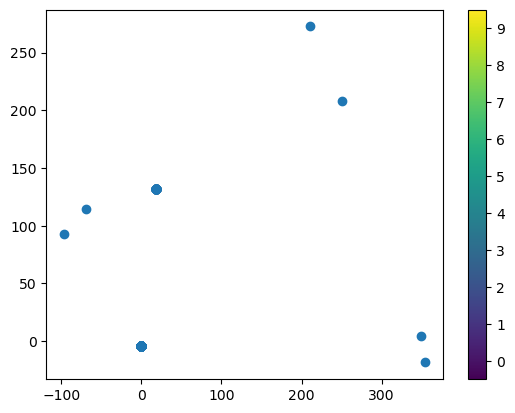

In [37]:
# plt.figure(figsize=(8, 8))
# plt.scatter(x = reduced[:,0], y=reduced[:,1])
# plt.show()
from collections import Counter

vis_x = reduced[:, 0]
vis_y = reduced[:, 1]

plt.scatter(vis_x, vis_y, cmap=plt.cm.get_cmap("jet", 10))
plt.colorbar(ticks=range(10))
plt.clim(-0.5, 9.5)
plt.show()

In [38]:
reduced_transformed = reduced - np.min(reduced, axis=0)
reduced_transformed /= np.max(reduced_transformed, axis=0)
image_xindex_sorted = np.argsort(np.sum(reduced_transformed, axis=1))
print(image_xindex_sorted.shape)

(3308,)


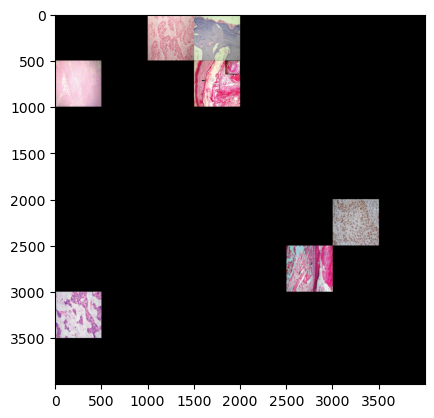

In [39]:
# draw all images in a merged image
no_of_images=50
from PIL import Image
image_width = 500
merged_width = int(np.ceil(np.sqrt(no_of_images))*image_width)
merged_image = np.zeros((merged_width, merged_width, 3), dtype='uint8')
ellipside =True
for counter, index in enumerate(image_xindex_sorted):
    # set location
    if ellipside:
        a = np.ceil(reduced_transformed[counter, 0] * (merged_width-image_width-1)+1)
        b = np.ceil(reduced_transformed[counter, 1] * (merged_width-image_width-1)+1)
        a = int(a - np.mod(a-1,image_width) + 1)
        b = int(b - np.mod(b-1,image_width) + 1)
        if merged_image[a,b,0] != 0:
            continue
        image_address = images[counter]
        img = np.asarray(Image.open('Desktop/pubmed_set/images/'+image_address).resize((image_width, image_width)))
        merged_image[a:a+image_width, b:b+image_width,:] = img[:,:,:3]
    else:
        b = int(np.mod(counter, np.sqrt(no_of_images)))
        a = int(np.mod(counter//np.sqrt(no_of_images), np.sqrt(no_of_images)))
        image_address = images[index]
        print(image_address)
        img = np.asarray(Image.open('Desktop/pubmed_set/images/'+image_address).resize((image_width, image_width)))
        merged_image[a*image_width:(a+1)*image_width, b*image_width:(b+1)*image_width,:] = img[:,:,:3]

plt.imshow(merged_image)
plt.show()
merged_image = Image.fromarray(merged_image)
if ellipside:
    merged_image.save('merged-%s-ellipsoide-resnet50.png'%images_path.split('/')[-2])
else:
    merged_image.save('merged-%s.png'%images_path.split('/')[-2])

In [40]:
img_path= '/Users/aditibelle/Desktop/pubmed_set/images/0a6fc26c-9cd9-4f95-8273-0a416457c92e.jpg'
from pathlib import Path
test = Path('/Users/aditibelle/Dimages/bfce72df-d774-4641-b1f9-7849efa080ad.jpg')
test.is_file()

False

In [41]:
#from tensorflow.contrib.tensorboard.plugins import projector

import tensorflow as tf
from tensorboard.plugins import projector

In [42]:
embeddings_path = '/Users/aditibelle/Desktop/Embeddings'
LOG_DIR = '/Users/aditibelle/Desktop/Embeddings_Log'

In [43]:
features.shape


(3308, 2048)

In [44]:
np.savetxt('feature_vectors_400_samples.txt',features)
#feature_vectors = np.loadtxt('feature_vectors.txt')
pickle.dump(features, open('feature_vectors_400_samples.pkl', 'wb'))

In [45]:
img_data=[]
print(images)



['bfce72df-d774-4641-b1f9-7849efa080ad.jpg', '96999c16-8506-40b8-9d82-4e6dc7bcf34b.jpg', '6f81441b-16b8-47d0-9c01-5a0de58638bc.jpg', 'a7044061-47f5-4eb2-9264-64bd87f3194d.jpg', '36b19f6b-d768-4322-861c-e086026f6509.jpg', '543b4355-4719-4405-9445-398a52200805.jpg', '4b386ba4-bf05-4607-8424-215271e94c91.jpg', '9d251eb2-8c21-4d5d-8fc8-1a71da6d2b23.jpg', 'ef95beea-db09-40b7-82be-854ec7d6b493.jpg', '5f12c1f9-8d83-4b9f-b9e4-13841dad33ab.jpg', '915ccb6a-47bf-4d22-843b-1d3ad3832eb6.jpg', '13979796-f938-4dca-923a-c43b2c881dcb.jpg', 'a31f0991-461e-4e1d-bd9e-6b7aad322f4a.jpg', 'b0d89fb0-b9ff-4674-b3c9-2af3dc6f8ed9.jpg', '75a6990c-f160-4eb6-92d3-2c2097a69ca9.jpg', 'd100a3b7-0e21-4a10-b1db-bbf61e944256.jpg', '78a70ff6-9d3b-4b5f-8a96-ff5b3dd33719.jpg', '8409587a-f004-46d5-9959-149c5a4d47a7.jpg', 'fdb1bd32-c30d-40e2-afe7-1521d8c202c0.jpg', '0be36a50-f04c-4cf2-a4fe-96dd2c4833d6.jpg', 'c54b3cd5-89a0-48d4-bea0-7732b95c1092.jpg', '13bdf70f-cb8e-436b-b310-3cd6044dcd7e.jpg', '7ce21cde-0373-47c7-9660-f39bda

In [46]:
for img in images:
    input_img=cv2.imread('Desktop/pubmed_set/images/'+img )
    input_img_resize=cv2.resize(input_img,(224,224))
    img_data.append(input_img_resize)
    
                
img_data = np.array(img_data)


In [48]:
import tensorflow as tf
import os
feature_vectors = np.loadtxt('feature_vectors_400_samples.txt')
print ("feature_vectors_shape:",feature_vectors.shape)
print ("num of images:",feature_vectors.shape[0])
print ("size of individual feature vector:",feature_vectors.shape[1])
features = tf.Variable(feature_vectors, name='features')
#images_name = ['tissue','cells']


#metadata_file = open(os.path.join(LOG_DIR, 'metadata_4_classes.tsv'), 'w')
#metadata_file.write('Class\tName\n')

#for i,label in enumerate(images_name):
    #c = images_name[images_name[i]]
    #metadata_file.write('{}\t{}\n'.format(i + 1, c))
    
#metadata_file.close()

feature_vectors_shape: (3308, 2048)
num of images: 3308
size of individual feature vector: 2048


In [49]:
def images_to_sprite(data):
    """Creates the sprite image along with any necessary padding

    Args:
      data: NxHxW[x3] tensor containing the images.

    Returns:
      data: Properly shaped HxWx3 image with any necessary padding.
    """
    if len(data.shape) == 3:
        data = np.tile(data[...,np.newaxis], (1,1,1,3))
    data = data.astype(np.float32)
    min = np.min(data.reshape((data.shape[0], -1)), axis=1)
    data = (data.transpose(1,2,3,0) - min).transpose(3,0,1,2)
    max = np.max(data.reshape((data.shape[0], -1)), axis=1)
    data = (data.transpose(1,2,3,0) / max).transpose(3,0,1,2)
    # Inverting the colors seems to look better for MNIST
    #data = 1 - data

    n = int(np.ceil(np.sqrt(data.shape[0])))
    padding = ((0, n ** 2 - data.shape[0]), (0, 0),
            (0, 0)) + ((0, 0),) * (data.ndim - 3)
    data = np.pad(data, padding, mode='constant',
            constant_values=0)
    # Tile the individual thumbnails into an image.
    data = data.reshape((n, n) + data.shape[1:]).transpose((0, 2, 1, 3)
            + tuple(range(4, data.ndim + 1)))
    data = data.reshape((n * data.shape[1], n * data.shape[3]) + data.shape[4:])
    data = (data * 255).astype(np.uint8)
    return data
#%%
sprite = images_to_sprite(img_data)
cv2.imwrite(os.path.join(LOG_DIR, 'sprite_4_classes.png'), sprite)

True

In [57]:

tf.compat.v1.disable_v2_behavior()
with tf.compat.v1.Session() as sess:
    saver = tf.compat.v1.train.Saver([features])

    sess.run(features.initializer)
    saver.save(sess, os.path.join(LOG_DIR, 'images_4_classes.ckpt'))
    
    config = projector.ProjectorConfig()
    # One can add multiple embeddings.
    embedding = config.embeddings.add()
    embedding.tensor_name = features.name
    # Link this tensor to its metadata file (e.g. labels).
    embedding.metadata_path = os.path.join(LOG_DIR, 'metadata_4_classes.tsv')
    # Comment out if you don't want sprites
    embedding.sprite.image_path = os.path.join(LOG_DIR, 'sprite_4_classes.png')
    embedding.sprite.single_image_dim.extend([img_data.shape[1], img_data.shape[1]])
    # Saves a config file that TensorBoard will read during startup.
    projector.visualize_embeddings(tf.summary.FileWriter(LOG_DIR), config)

Instructions for updating:
non-resource variables are not supported in the long term


RuntimeError: resource: Attempting to capture an EagerTensor without building a function.